In [2]:
import json
import numpy as np

fp = open("../archive/ch3/TestAccuracyForFiD_NQ_DEV_threshold0.8_K10_size1000.json")
data = json.load(fp)
fp.close()
fps = np.array(data["raw"]["pri_fusion_size"])
ex = np.array(data["raw"]["ex"])
ex_pub = np.array(data["raw"]["ex_pub"])
ex_pri = np.array(data["raw"]["ex_pri"])
f1 = np.array(data["raw"]["f1"])
f1_pub = np.array(data["raw"]["f1_pub"])
f1_pri = np.array(data["raw"]["f1_pri"])

In [6]:
fps = fps.reshape(2, -1, 1000)
flops = fps.sum(-1) * 768 

print(f"ex:\n {ex[1:].reshape(2, 5)}")
print(f"ex(%):\n {(ex / ex[0])[1:].reshape(2, -1).round(4) * 100}")
print(f"ex_pub(%):\n {(ex_pub / ex[0]).reshape(2, -1).round(4) * 100}")
print(f"ex_pri(%):\n {(ex_pri / ex[0]).reshape(2, -1).round(4) * 100}")

ex:
 [[0.409 0.392 0.389 0.403 0.411]
 [0.403 0.404 0.415 0.416 0.415]]
ex(%):
 [[97.85 93.78 93.06 96.41 98.33]
 [96.41 96.65 99.28 99.52 99.28]]
ex_pub(%):
 [[95.93 86.36 75.84 57.18 32.78]
 [95.93 86.36 75.84 57.18 32.78]]
ex_pri(%):
 [[32.06 61.96 82.78 89.95 96.65]
 [32.3  67.7  87.08 93.06 98.33]]


[0.73 2.45 6.36 5.38 0.  ]


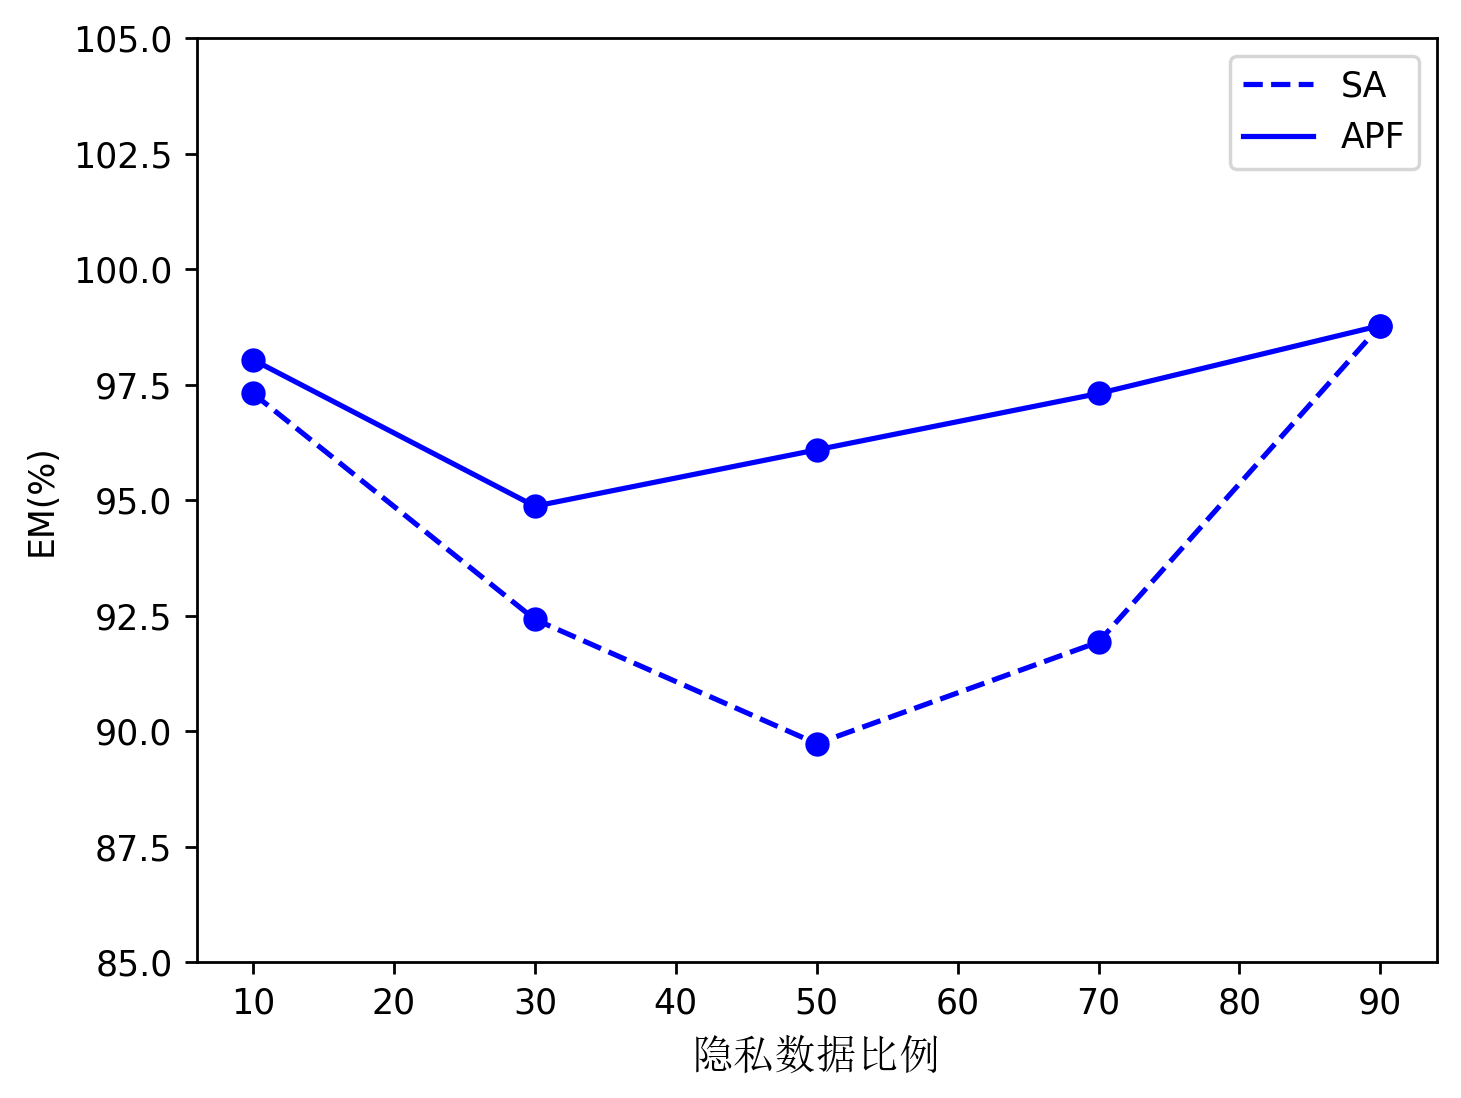

In [1]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


EM_TQA_K10_noadapt = (
    np.array([0.97310513, 0.92420538, 0.89731051, 0.9193154, 0.98777506]).round(4) * 100
)
EM_TQA_K10 = (
    np.array([0.9804401, 0.94865526, 0.9608802, 0.97310513, 0.98777506]).round(4) * 100
)
print(EM_TQA_K10 - EM_TQA_K10_noadapt)
x = np.linspace(10, 90, 5, dtype=int)
plt.figure(dpi=250)
plt.plot(x, EM_TQA_K10_noadapt, color="blue", linestyle="--", label="SA")
plt.scatter(x, EM_TQA_K10_noadapt, color="blue")
plt.plot(x, EM_TQA_K10, color="blue", label="APF")
plt.scatter(x, EM_TQA_K10, color="blue")
plt.ylim(85, 105)
plt.ylabel("EM(%)")
plt.xlabel("隐私数据比例", fontproperties=font)
plt.legend()

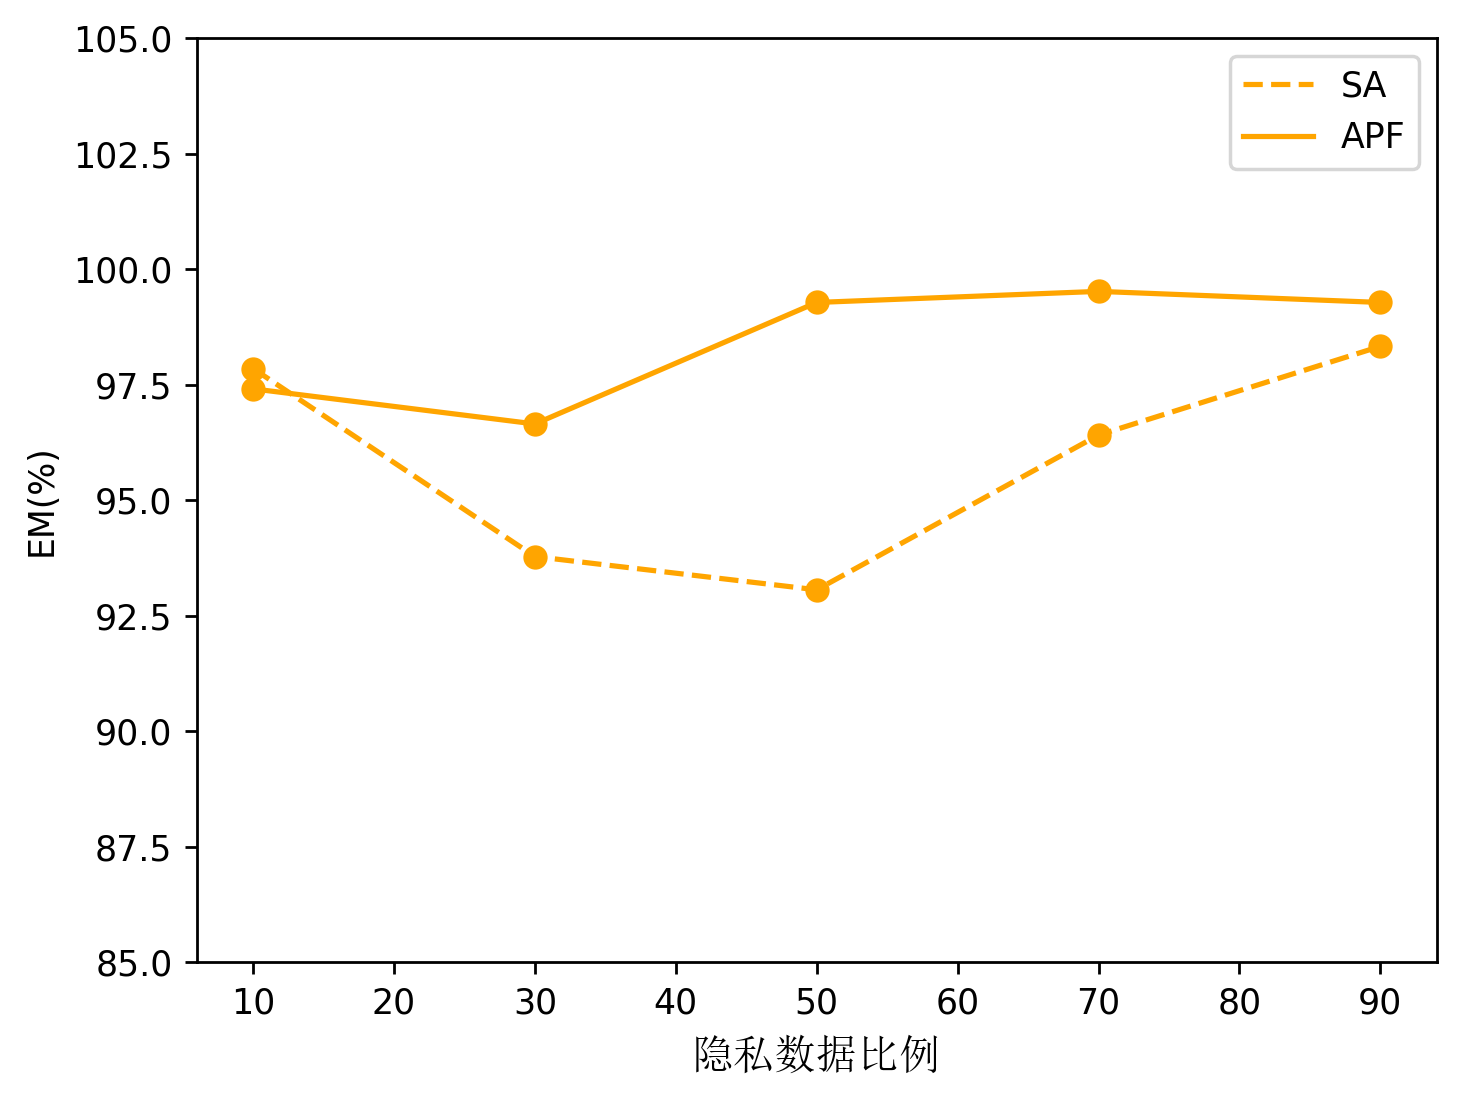

In [2]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


EM_NQ_K10_noadapt = [97.85, 93.78, 93.06, 96.41, 98.33]
EM_NQ_K10 = [97.41, 96.65, 99.28, 99.52, 99.28]
x = np.linspace(10, 90, 5, dtype=int)
plt.figure(dpi=250)
plt.plot(x, EM_NQ_K10_noadapt, color="orange", linestyle="--", label="SA")
plt.scatter(x, EM_NQ_K10_noadapt, color="orange")
plt.plot(x, EM_NQ_K10, color="orange", label="APF")
plt.scatter(x, EM_NQ_K10, color="orange")
plt.ylim(85, 105)
plt.ylabel("EM(%)")
plt.xlabel("隐私数据比例", fontproperties=font)
plt.legend()

In [87]:
import json
import numpy as np


def fn():
    lst = []
    for th in [0.7, 0.8, 0.9]:
        path = f"../archive/ch3/TestAccuracyForFiD_NQ_DEV_threshold{th}_K10_size1000.json"
        fp = open(path)
        data = json.load(fp)
        fp.close()
        pfs = np.array(data["raw"]["pri_fusion_size"])
        if sum(pfs.shape) == 5000:
            # print(f"pfs\n{pfs.reshape(5, 1000).mean(-1)}")
            lst.append(pfs.reshape(5, 1000).mean(-1))
        if sum(pfs.shape) == 10000:
            # print(f"pfs\n{pfs.reshape(2, 5, 1000)[1].mean(-1)}")
            lst.append(pfs.reshape(2, 5, 1000)[1].mean(-1))
    lst = np.array(lst)
    print((lst / 10).round(2))

fn()

[[0.11 0.34 0.55 0.73 0.91]
 [0.13 0.41 0.59 0.75 0.91]
 [0.19 0.53 0.67 0.79 0.92]]


In [1]:
import json
import numpy as np


def fn():
    # path1 = "../archive/ch3/is_adaptive_True.json"
    # path2 = "../tmp/native.json"
    path1 = "../tmp/is_adaptive_True_thre0.9_k10_s100_e.json"
    path2 = "../tmp/native_k10_s100.json"
    fp = open(path1)
    data = json.load(fp)
    fp.close()
    dt = np.array(data["raw"]["cpu_DECODER"])
    et = np.array(data["raw"]["cpu_ENCODER"])
    # prs = np.array(data["raw"]["pri_fusion_size"])
    rds = np.array(data["raw"]["required_dep_size"])
    tokens = np.array(data["raw"]["TOKENS_TEE"])
    sdt = np.array(data["raw"]["DECODER_TIMER"])
    fp = open(path2)
    data = json.load(fp)
    fp.close()
    native_et = np.array(data["raw"]["cpu_ENCODER"])
    native_dt = np.array(data["raw"]["cpu_DECODER"])

    load_size = 100

    totaltime = dt + et
    totaltime_ = totaltime.reshape(2, 5, load_size).sum(-1)
    print(f"totaltime\n{(totaltime_ / totaltime_[0])[1].round(4) * 100}")
    native_totaltime = native_et + native_dt
    native_totaltime = np.broadcast_to(native_totaltime, (2, 5, load_size))
    native_totaltime_ = native_totaltime.sum(-1)
    print(f"totaltime\n{(native_totaltime_ / totaltime_).round(2)}")
    mask_ = rds.reshape(2, 5, load_size) > 0
    # mask_ = ~mask_
    native_totaltime_ = np.where(mask_, native_totaltime, 0).sum(-1)
    totaltime_ = np.where(mask_, totaltime.reshape(2, 5, load_size), 0).sum(-1)
    print(f"totaltime\n{(native_totaltime_ / totaltime_).round(2)}")

    rds_ = rds.reshape(2, 5, load_size).sum(-1)
    print(f"rds\n{(rds_[1])}")

    et_ = et.reshape(2, 5, load_size).sum(-1)
    print(f"encodertime\n{et_}")
    print(f"encodertime\n{(et_ / et_[0])[1].round(4) * 100}")

    dt_ = dt.reshape(2, 5, load_size).sum(-1)
    print(f"decodertime\n{dt_}")
    print(f"decodertime\n{(dt_ / dt_[0])[1].round(4) * 100}")

    mask_ = rds.reshape(2, 5, load_size) > 0
    dt_ = dt.reshape(2, 5, load_size)
    dt_ = np.where(mask_, dt_, 0).sum(-1)
    print(f"adpativetime\n{(dt_ / dt_[0])[1].round(4) * 100}")

    tkcum_ = (tokens - 1).cumsum()
    tkcum_ = np.insert(tkcum_, 0, 0)[:-1]
    sdt_ = sdt[tkcum_].reshape(2, 5, load_size)
    mask_ = rds.reshape(2, 5, load_size) > 0
    sdt_ = np.where(mask_, sdt_, 0).sum(-1)
    print(f"sdt_\n{sdt_}")
    print(f"sdt_\n{(sdt_ / sdt_[0])[1].round(4) * 100}")


fn()

totaltime
[ 94.21  86.61 103.18 103.99 106.38]
totaltime
[[2.73 1.5  1.49 1.41 1.2 ]
 [2.9  1.73 1.44 1.36 1.12]]
totaltime
[[1.51 1.27 1.37 1.35 1.14]
 [1.71 1.47 1.33 1.27 1.11]]
rds
[109 235 160  82  17]
encodertime
[[22.29688334 52.82480741 52.77436686 56.57584834 68.68386841]
 [20.19700646 44.0723989  55.07246137 59.46676064 74.74303532]]
encodertime
[ 90.58  83.43 104.35 105.11 108.82]
decodertime
[[20.53969479 25.36739755 25.97619724 26.38628054 29.21431422]
 [20.15793633 23.65286708 26.18200469 26.80489755 29.40400028]]
decodertime
[ 98.14  93.24 100.79 101.59 100.65]
adpativetime
[ 92.41  92.64 100.3  102.58  97.65]
sdt_
[[2.91623878 8.60180783 8.68999004 7.51876426 2.58513761]
 [2.51045179 7.47045279 8.67616224 8.03735399 2.54178834]]
sdt_
[ 86.09  86.85  99.84 106.9   98.32]


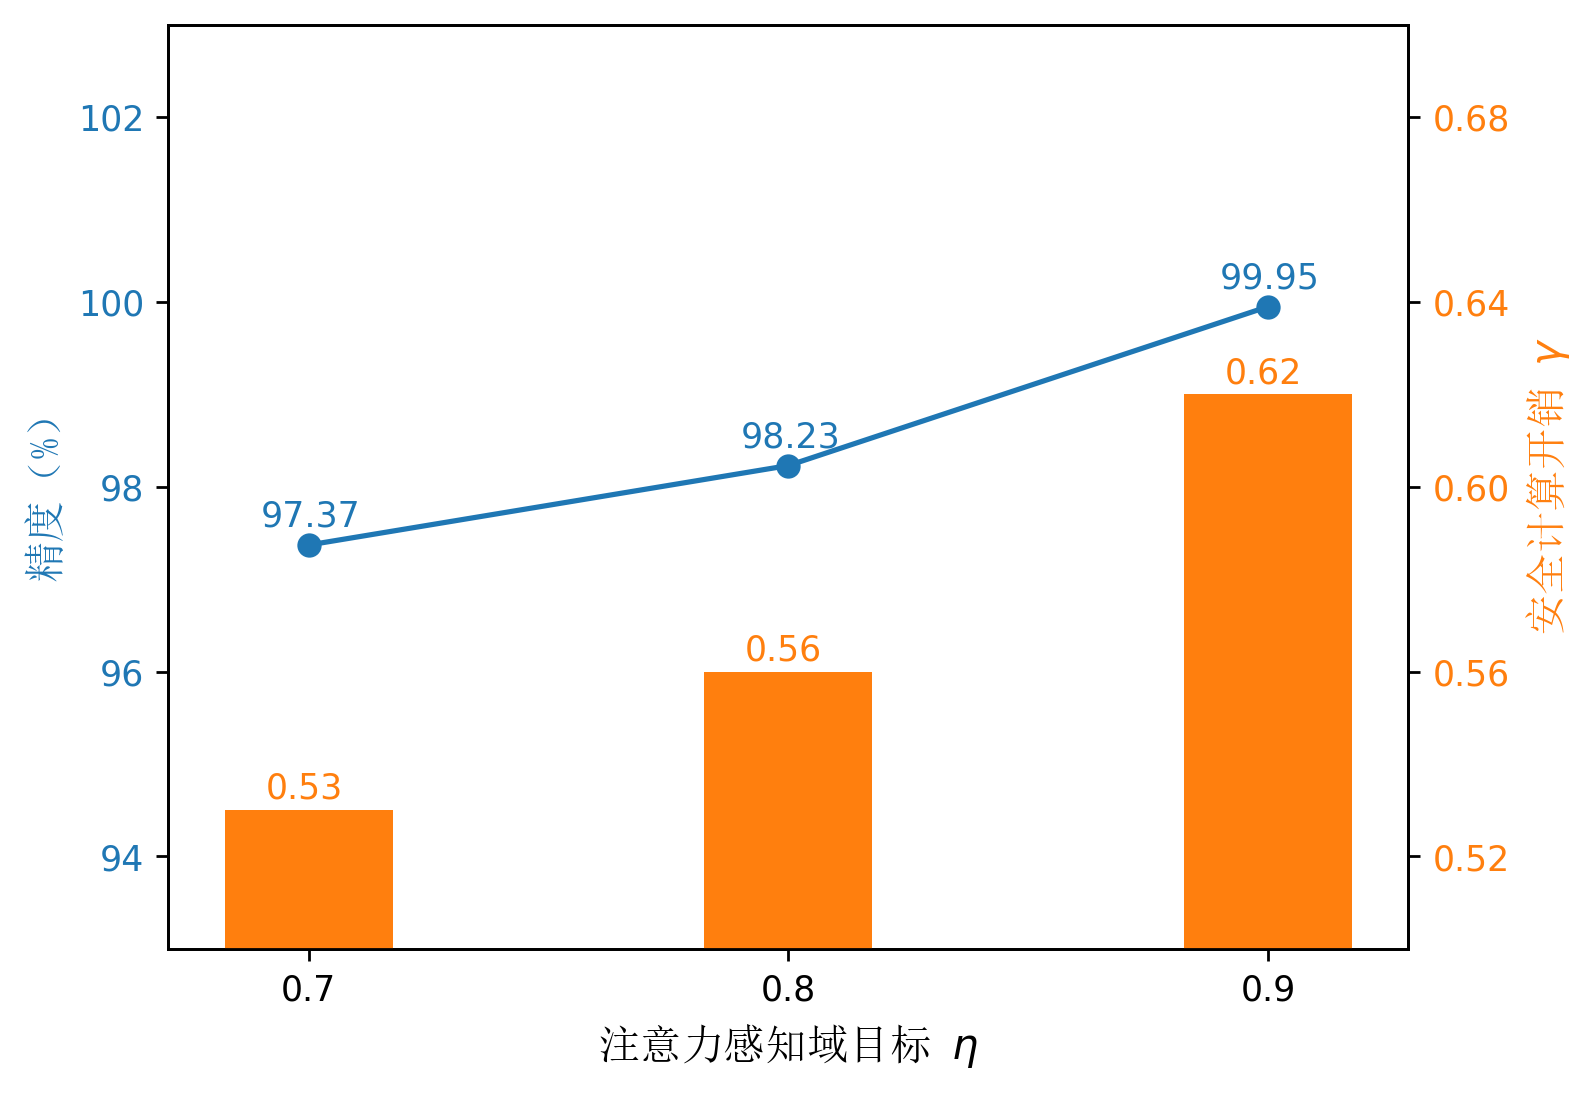

In [85]:
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MaxNLocator

import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)

acc = [97.37, 98.23, 99.95]
eff = [0.53, 0.56, 0.62]
x = [0.7, 0.8, 0.9]

fig, ax1 = plt.subplots(dpi=250)

# 左轴 (Accuracy)
ax1.plot(x, acc, color='tab:blue')
ax1.scatter(x, acc, color='tab:blue')
ax1.set_ylim(93, 103)
ax1.set_ylabel('精度（%）', color='tab:blue', fontproperties=font)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(x)
for a, b in zip(x, acc):
    ax1.text(a - 0.01, b + 0.2, b, color="tab:blue")

# 右轴 (Efficiency)
ax2 = ax1.twinx()
ax2.bar(x, eff, width=0.035, color='tab:orange')
ax2.set_ylim(0.5, 0.7)
ax2.set_ylabel(r'安全计算开销 $\gamma$', color='tab:orange', fontproperties=font)
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.yaxis.set_major_locator(MaxNLocator(5))

for a, b in zip(x, eff):
    ax2.text(a - 0.009, b + 0.0025, b, color='tab:orange')

ax1.set_xlabel(r"注意力感知域目标 $\eta$", fontproperties=font)
plt.show()